# Identification of factors

In this notebook, we use the already trained DRVI model on the immune dataset to show different ways to identify a factor. In summary we can:

- Identify based on available annotation
- Identify using GSEA
- Identify using Language models
- Looking into the annotation databases

**We always advise examination by a biologist or looking into the published litereture for validation of the identified processes.**

## Intro

In this notrbook, we assume that the user has already trained DRVI on Immune data.

Please refer to [General training and interpretability pipeline](./general_pipeline.html) tutorial.

## Contact

For questions and help requests, you can reach out in the [scverse discourse](https://discourse.scverse.org/).

If you found a bug, please use the [issue tracker](https://github.com/theislab/drvi/issues).

## Install

If you try DRVI on colab, next cell will install dependencies.

Please remove this part if your environment is already setup.

In [28]:
import sys

# if branch is stable, will install via pypi, else will install from source
branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    !pip install multigrate[tutorials]
elif IN_COLAB and branch != "stable":
    !pip install git+https://github.com/theislab/drvi.git#egg=drvi[tutorials]

## Imports

In [29]:
import warnings
warnings.filterwarnings("ignore")

In [30]:
import anndata as ad
import scanpy as sc

import scvi
import drvi
from pathlib import Path
from drvi.model import DRVI
from drvi.utils.misc import hvg_batch

In [31]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.0.post1
Last run with DRVI version: 0.2.1


## Config

In [32]:
# Set this to false if you already trained your model and do not like to retrain.
overwrite = False
SEED = 1  # Set to None if you don't want to set seed

# Set input output directory
# We use tmp_io/ directory in the same place as this notebook. Update accordingly.
io_dir = Path("./tmp_io/drvi_immune_128/")
io_dir.mkdir(parents=True, exist_ok=True)
io_dir

PosixPath('tmp_io/drvi_immune_128')

## Load Data

In [33]:
# We already saved pre-processed data in previous notebook
adata = sc.read_h5ad(io_dir / "adata_preprocesses.h5ad")

## Load DRVI ouputs

In [34]:
model_path = io_dir / "drvi_model"
embed_path = io_dir / "embed.h5ad"
traverse_adata_path = io_dir / "traverse_adata.h5ad"

model = DRVI.load(model_path, adata)
embed = sc.read_h5ad(embed_path)
traverse_adata = sc.read_h5ad(traverse_adata_path)

INFO     File tmp_io/drvi_immune_128/drvi_model/model.pt already downloaded                                        
INFO     DRVI: The model is trained with DRVI version 0.2.1.                                                       
INFO     DRVI: Loading source in DRVI version 0.2.1.                                                               
INFO     DRVI: The model has been initialized                                                                      


## Identify based on available annotations

In this dataset we have annotations stored in `adata.obs["final_annotation"]`.

We first measure Scaled Mutual Information (SMI) between each latent dimension and each category using DRVI built-in functions.

In [35]:
annot_col = "final_annotation"

### Specific Imports

In [36]:
import math
import networkx as nx
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

### Helper functions

In [37]:
def plot_packed_network(df, title_col='title', var_col='variable', val_col='value'):
    """
    Visualizes network with edge weights shown to 2 decimal places.
    """
    # Create Graph
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)
    
    # Custom Grid Layout Logic
    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = math.ceil(len(components)**0.5)
    
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=(14, 10))
    titles = set(df[title_col])
    
    # Draw Nodes & Edges
    nx.draw(G, pos, 
            with_labels=True, font_size=8, font_weight='bold', node_size=600,
            node_color=['#A0CBE2' if n in titles else '#FF9E9E' for n in G.nodes()],
            width=[d[val_col] * 4 for u, v, d in G.edges(data=True)], 
            edge_color='grey', alpha=0.6)
    
    # Draw Edge Labels (Weights rounded to 2 decimals)
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
            
    plt.axis('off')
    plt.show()

### Code

In [38]:
# Remove vanished dimensions
embed_nv = embed[:, embed.var['vanished'] == False].copy()
embed_nv

AnnData object with n_obs × n_vars = 32484 × 61
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', '_scvi_batch', '_scvi_labels'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [39]:
benchmark = DiscreteDisentanglementBenchmark(
    embed_nv.X, dim_titles=embed_nv.var['title'], discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc", "SPN"], aggregation_methods=["LMS"],
)
benchmark.evaluate()
# You can optionally save benchmark object if you want.
# benchmark.save(filename)
# benchmark = DiscreteDisentanglementBenchmark.load(filename, embed_nv.X, dim_titles=embed_nv.var['title'], discrete_target=embed.obs["final_annotation"], metrics=["SMI-disc", "SPN"], aggregation_methods=["LMS"])

In [40]:
smi_similarity = benchmark.get_results_details()["SMI-disc"]
smi_similarity[:5]  # only showing 5 rows

,CD4+ T cells,CD8+ T cells,CD10+ B cells,CD14+ Monocytes,CD16+ Monocytes,CD20+ B cells,Erythrocytes,Erythroid progenitors,HSPCs,Megakaryocyte progenitors,Monocyte progenitors,Monocyte-derived dendritic cells,NK cells,NKT cells,Plasma cells,Plasmacytoid dendritic cells
title,,,,,,,,,,,,,,,,
DR 36,0.021124,0.007055,0.013579,0.005682,0.003340,0.006009,0.012808,0.025647,0.141675,0.147504,0.652945,0.023091,0.009346,0.006856,0.019912,0.010587
DR 49,0.058937,0.010312,0.003151,0.115108,0.019689,0.012800,0.006262,0.002189,0.002379,0.001219,0.001292,0.004543,0.008689,0.017035,0.859131,0.003900
DR 33,0.030350,0.011059,0.030578,0.021986,0.009531,0.011717,0.048552,0.468666,0.061815,0.370950,0.022623,0.007081,0.010243,0.011877,0.009066,0.005726
DR 38,0.017637,0.007678,0.008826,0.008149,0.012777,0.123699,0.004518,0.050416,0.004173,0.049967,0.008930,0.026165,0.005970,0.006707,0.018673,0.009291
DR 2,0.140299,0.080318,0.033397,0.761070,0.048512,0.084590,0.070976,0.036295,0.033788,0.033796,0.033385,0.107270,0.063494,0.064894,0.035367,0.038994


In [41]:
filtering_threshold = 0.5

top_matches = (
    smi_similarity.reset_index()
    .melt(id_vars='title', value_vars=smi_similarity.columns)
    .query("value >= @filtering_threshold")
    .reset_index(drop=True)
)
top_matches

,title,variable,value
0,DR 1,CD4+ T cells,0.535119
1,DR 41,CD10+ B cells,0.668039
2,DR 53,CD10+ B cells,0.773828
3,DR 31,CD10+ B cells,0.659314
4,DR 2,CD14+ Monocytes,0.761070
5,DR 3,CD14+ Monocytes,0.878655
6,DR 26,CD16+ Monocytes,0.661827
7,DR 9,CD16+ Monocytes,0.910748
8,DR 5,CD20+ B cells,0.758002
9,DR 7,CD20+ B cells,0.654006


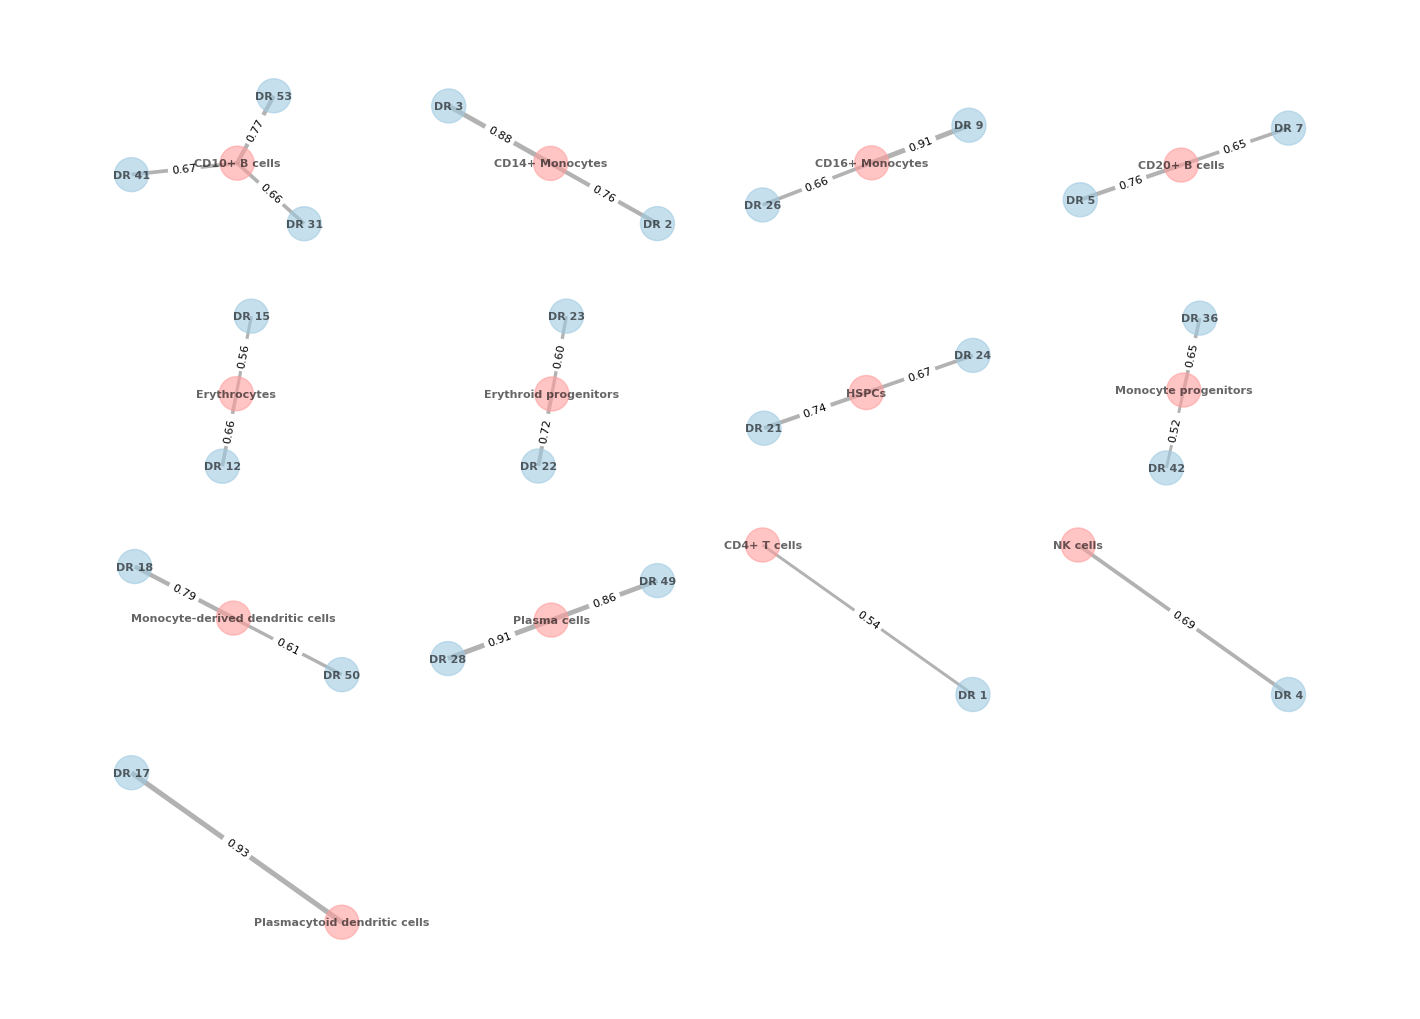

In [42]:
plot_packed_network(top_matches)

#### Heatmap

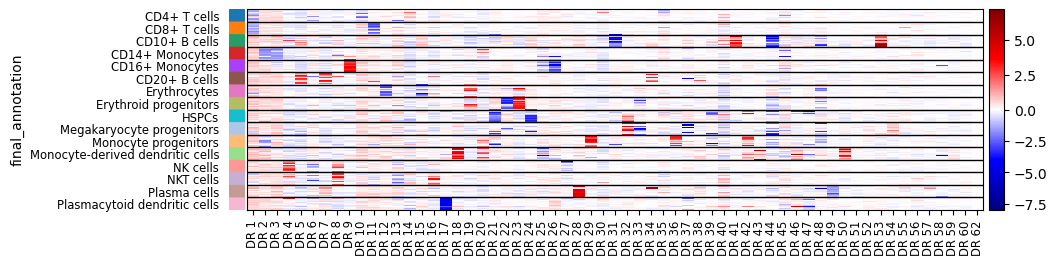

In [43]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, "final_annotation", title_col="title")

It is possible to sort dimensions based on the top relevance with respect to a categoricals variable

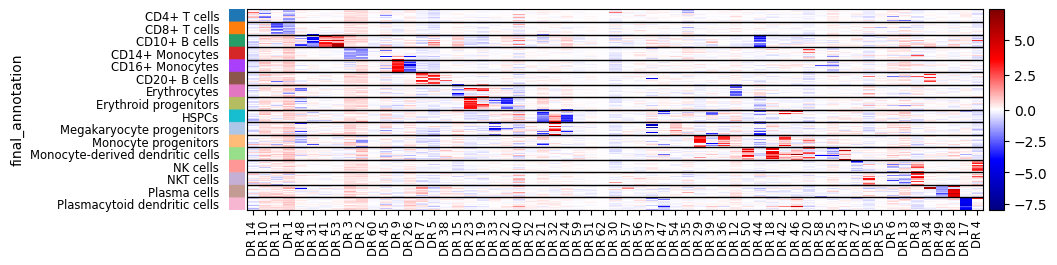

In [44]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, "final_annotation", title_col="title", sort_by_categorical=True)

## Identification of programs

Once we identify the top relevant genes, we can determine some programs through supervised external information, such as:
- existing annotations
- examination by biologists
- gene-set enrichment analysis (GSEA)
- scientific literature
- automated tools based on language models

**Please refer to this tutorial for some tools that we found useful for identification of programs**

It is worth mentioning that since such supervised information is not given to the model, the quality of the derived signatures is neither affected nor biased by it. Unidentified processes with high gene scores are promising candidates for further literature search, additional analysis, and even experimental design.

1. Input: 
-Gene list?
-Ranked list?
Expression Correlation with known Zelltype Markers
2. Reference Databases: 
-Classic Datatabases: Gene Ontology, Reactome, MSigDB? 
-Celltype specific Data (Cell Typist)
-LLMs: gsai?
3. Annotation Method:
-Over-representation
-Regressions based: How well does a set of genes explain a factor




# Exploration Roadmap: DRVI Factor Annotation Pipeline

This roadmap outlines the systematic evaluation of tools for annotating latent factors. The goal is to move from abstract dimensions to interpretable biological processes using the immune dataset as a pilot.

### 1. Statistical Annotation & Similarity 

Goal: Map latent factors to known cell types using existing annotations and atlases.

Tools to Compare:
* CellTypist: Utilizing the Immune_All_Low.pkl or High models for automated labeling.
* Single R
* Reference Mapping (Scanpy Ingest/scArches): Projecting query data onto a high-quality PBMC/Immune atlas.
* Direct Regression: Using a Logistic Regression classifier to see if factors linearly predict known cell types.

Key Metrics:
* LMS-SMI (Scaled Mutual Information): Measures the exclusivity of a factor for a specific label. High SMI = high disentanglement.
* LMS-SPN (Same-Process Neighbors): Evaluates if cells with the same annotation are closer in the latent space.
* Diagonalization: Visual assessment via Heatmaps to see if factors have 1-to-1 mappings to cell types.

#### 1.1 Cell Typist

* Input: normalized gene expression matrix of cells
* Reference: Pre-trained Logistic Regression models trained on millions of annotated cells in different tissues
* Algorithm: Linear Classification --> Calculates Decision Scores via linear combination of scaled expression and model coefficients, followed by a Maximum Score selection for identity.
* Output: 
    * Predicted Labels: Final call for each cell
    * Decision Matrix: Raw classification scores
    * Probability Matrix: Sigmoid-transformed scores (0 to 1)





##### Importing Libraries

In [45]:
import celltypist
from celltypist import models
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

##### Setup and Load data

In [46]:
#make sure indices of adata and embed are the same, so we can transfer factors to adata object

#Load data
embed = sc.read_h5ad("/Users/clara.sanchez/Documents/code/drvi_project/drvi_tutorials/tmp_io/drvi_immune_128/embed.h5ad")
adata = sc.read_h5ad("/Users/clara.sanchez/Documents/code/drvi_project/drvi_tutorials/tmp_io/drvi_immune_128/adata_preprocesses.h5ad")  

#Synchronize barcodes
common_cells = adata.obs_names.intersection(embed.obs_names)
adata = adata[common_cells].copy()
embed = embed[common_cells].copy()

#Transfer factors
for i in range(embed.X.shape[1]):
    adata.obs[f'DRVI_F_{i}'] = embed.X[:, i]

print(f"Synchronized! Both objects have {adata.n_obs} cells.")

Synchronized! Both objects have 32484 cells.


##### Download Celltypist Model

In [47]:
#download celltypist model
print(models.models_description())
model_name = 'Immune_All_Low.pkl'
model = models.download_models(force_update=True, model=model_name)


#download recommended model for immune cells
model = models.Model.load(model = 'Immune_All_Low.pkl')

print(model.cell_types)


👉 Detailed model information can be found at `https://www.celltypist.org/models`
📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 60


                                      model  \
0                        Immune_All_Low.pkl   
1                       Immune_All_High.pkl   
2                    Adult_COVID19_PBMC.pkl   
3   Adult_CynomolgusMacaque_Hippocampus.pkl   
4                       Adult_Human_MTG.pkl   
5           Adult_Human_PancreaticIslet.pkl   
6          Adult_Human_PrefrontalCortex.pkl   
7                      Adult_Human_Skin.pkl   
8                  Adult_Human_Vascular.pkl   
9                       Adult_Mouse_Gut.pkl   
10            Adult_Mouse_OlfactoryBulb.pkl   
11                Adult_Pig_Hippocampus.pkl   
12      Adult_RhesusMacaque_Hippocampus.pkl   
13                Adult_cHSPCs_Illumina.pkl   
14                  Adult_cHSPCs_Ultima.pkl   
15                 Autopsy_COVID19_Lung.pkl   
16         COVID19_HumanChallenge_Blood.pkl   
17             COVID19_Immune_Landscape.pkl   
18                   Cells_Adult_Breast.pkl   
19                     Cells_Fetal_Lung.pkl   
20           

📂 Storing models in /Users/clara.sanchez/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl


['Age-associated B cells' 'Alveolar macrophages' 'B cells'
 'CD16+ NK cells' 'CD16- NK cells' 'CD8a/a' 'CD8a/b(entry)' 'CMP'
 'CRTAM+ gamma-delta T cells' 'Classical monocytes' 'Cycling B cells'
 'Cycling DCs' 'Cycling NK cells' 'Cycling T cells'
 'Cycling gamma-delta T cells' 'Cycling monocytes' 'DC' 'DC precursor'
 'DC1' 'DC2' 'DC3' 'Double-negative thymocytes'
 'Double-positive thymocytes' 'ELP' 'ETP' 'Early MK' 'Early erythroid'
 'Early lymphoid/T lymphoid' 'Endothelial cells' 'Epithelial cells'
 'Erythrocytes' 'Erythrophagocytic macrophages' 'Fibroblasts'
 'Follicular B cells' 'Follicular helper T cells' 'GMP'
 'Germinal center B cells' 'Granulocytes' 'HSC/MPP' 'Hofbauer cells' 'ILC'
 'ILC precursor' 'ILC1' 'ILC2' 'ILC3' 'Intermediate macrophages'
 'Intestinal macrophages' 'Kidney-resident macrophages' 'Kupffer cells'
 'Large pre-B cells' 'Late erythroid' 'MAIT cells' 'MEMP' 'MNP'
 'Macrophages' 'Mast cells' 'Megakaryocyte precursor'
 'Megakaryocyte-erythroid-mast cell progenitor'

##### Annotate Cells

In [48]:
#Annotation
predictions = celltypist.annotate(adata, model = 'Immune_All_Low.pkl', majority_voting = True)
adata.obs['celltypist_labels'] = predictions.predicted_labels['predicted_labels']
adata.obs['celltypist_majority'] = predictions.predicted_labels['majority_voting']

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 32484 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 1569 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


##### Extract Probability Matrix

In [49]:
# The Decision Matrix contains raw logit scores (useful for confidence checks)
decision_matrix = predictions.decision_matrix

# The Probability Matrix contains sigmoid-transformed scores (0 to 1)
# This is the primary input for the factor correlation analysis
prob_matrix = predictions.probability_matrix
prob_matrix.index = adata.obs_names

# Quick check: How many cell types did the model find?
print(f"Modell knows {prob_matrix.shape[1]} different Immune cell types.")

Modell knows 98 different Immune cell types.


##### Quantitative Evaluation (Correlation with DRVI factors)

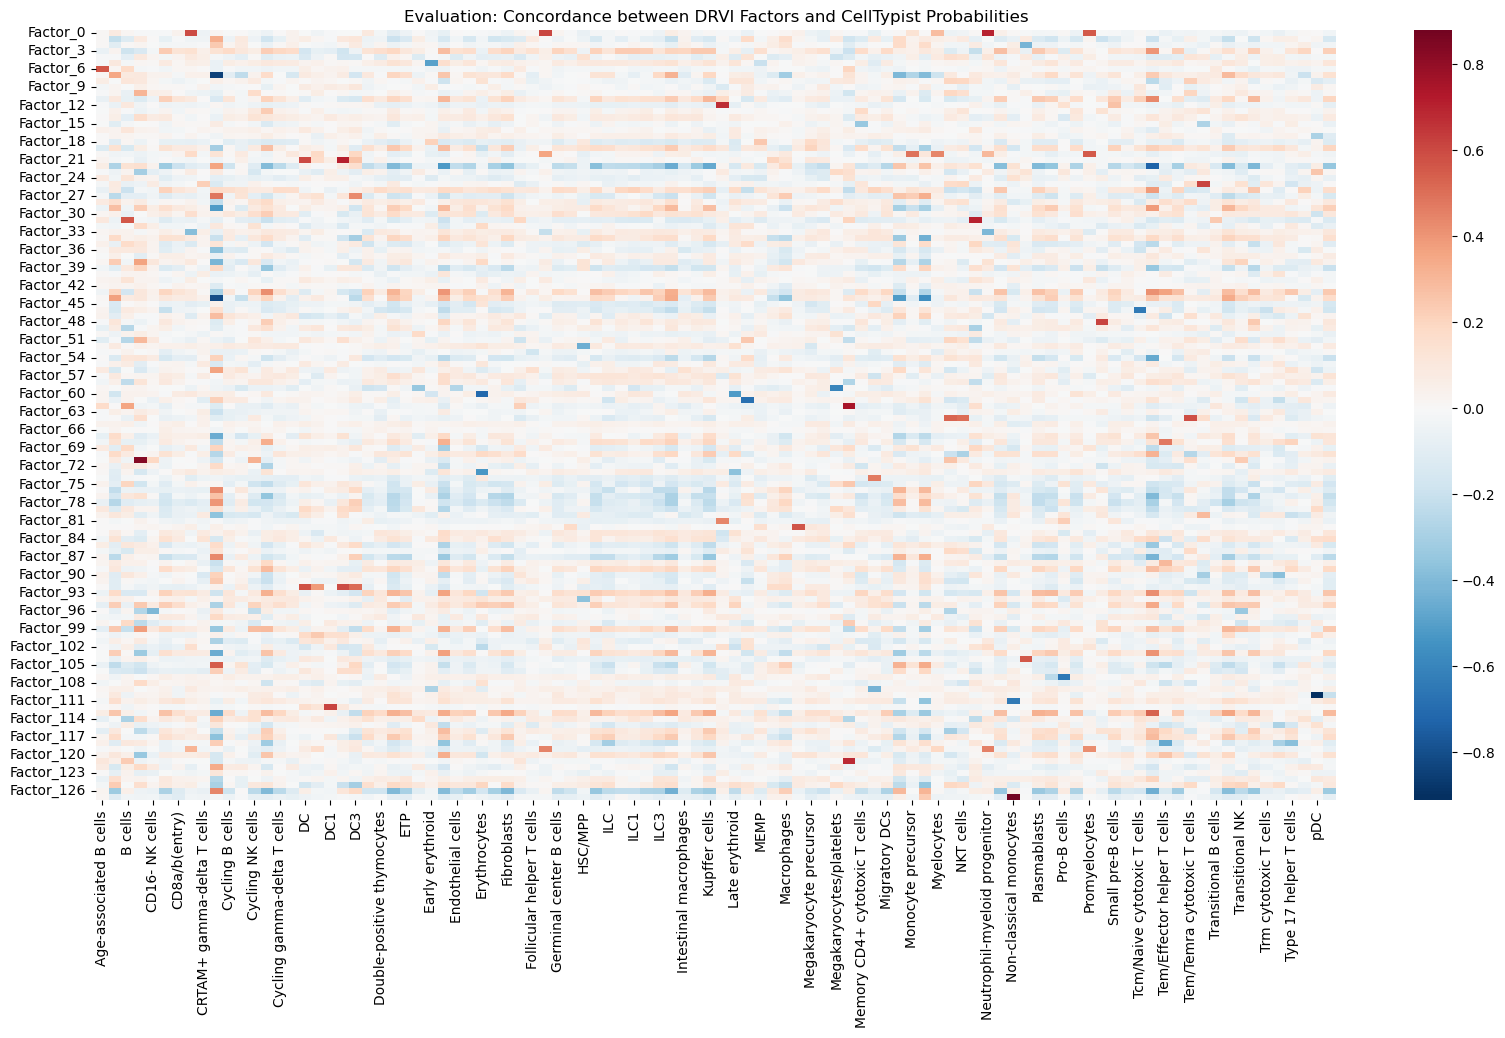

In [50]:
# Extract DRVI factors from the latent representation
## The .X matrix  contains the latent representations
adata.obsm['X_drvi'] = embed.X

drvi_factors = pd.DataFrame(adata.obsm['X_drvi'], index=adata.obs_names)
drvi_factors.columns = [f'Factor_{i}' for i in range(drvi_factors.shape[1])]

# Calculate Correlation between each Factor and each CellTypist Identity
eval_matrix = pd.DataFrame(
    np.corrcoef(drvi_factors.T, prob_matrix.T)[:drvi_factors.shape[1], drvi_factors.shape[1]:],
    index=drvi_factors.columns,
    columns=prob_matrix.columns
)

# Plotting the Evaluation Heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(eval_matrix, cmap='RdBu_r', center=0)
plt.title("Evaluation: Concordance between DRVI Factors and CellTypist Probabilities")
plt.show()

#### Factor Assignment Table with a Specificity Score

In [51]:
# 1. Extract the Top Match and the second-best match using 'eval_matrix'
top_1 = eval_matrix.idxmax(axis=1)
top_1_val = eval_matrix.max(axis=1)

# To find the 2nd best, we temporarily mask the top one
temp_matrix = eval_matrix.copy()
for i, col in enumerate(top_1):
    temp_matrix.loc[temp_matrix.index[i], col] = -1
top_2_val = temp_matrix.max(axis=1)

# 2. Calculate Specificity Score
specificity = top_1_val - top_2_val

# 3. Create the Quantification Table
quant_df = pd.DataFrame({
    'Factor': eval_matrix.index,
    'Top_CellType': top_1.values,
    'Correlation': top_1_val.values,
    'Specificity': specificity.values
}).sort_values('Correlation', ascending=False)

# 4. Filter for "Identified" factors (Correlation > 0.4)
identified_factors = quant_df[quant_df['Correlation'] > 0.4]

print(f"Quantification Summary:")
print(f"- Total Factors evaluated: {len(quant_df)}")
print(f"- Successfully assigned (Corr > 0.4): {len(identified_factors)}")
print(f"- Highly Specific (> 0.2 Gap): {len(quant_df[quant_df['Specificity'] > 0.2])}")

quant_df.head(10)

Quantification Summary:
- Total Factors evaluated: 128
- Successfully assigned (Corr > 0.4): 32
- Highly Specific (> 0.2 Gap): 14


,Factor,Top_CellType,Correlation,Specificity
127,Factor_127,Non-classical monocytes,0.879055,0.644343
71,Factor_71,CD16+ NK cells,0.834108,0.511472
62,Factor_62,Memory B cells,0.748783,0.392919
21,Factor_21,DC2,0.710290,0.105010
31,Factor_31,Naive B cells,0.700203,0.138204
0,Factor_0,Neutrophil-myeloid progenitor,0.697754,0.089356
121,Factor_121,Memory B cells,0.678380,0.446901
12,Factor_12,Large pre-B cells,0.670493,0.403575
25,Factor_25,Tem/Trm cytotoxic T cells,0.618886,0.402161
48,Factor_48,Regulatory T cells,0.615632,0.375146


### 2. Gene Set Enrichment Analysis (Functional Identity)

Goal: Identify biological processes (e.g., "Interferon Response", "Cell Cycle") for factors that do not map 1-to-1 to a cell type.

Tools to Compare:
* gProfiler (gprofiler-official): The benchmark used in the DRVI preprint
* Gseapy: Python implementation for local Enrichment analysis (Enrichr/MSigDB)
* Decoupler: A fast framework for footprint-based enrichment (e.g., PROXIMA)
* Blitzqseq

Key Metrics:

### 3. Language Model Based Identification (Advanced Annotation)

Goal: Automate "narrative" annotation and validation using LLMs.

Tools to Compare:
* gsai (Gene Set AI): Specialized LLM tool for gene list interpretation.
* Direct LLM Prompting: Using GPT-4/Claude via API to summarize factor-defining genes.
* OpenScholar: For literature-backed validation of the proposed factor names.

Key Metrics:

### 4. Final Integration & Verification

Goal: Create the final notebook structure to guide the user.

Implementation:
* Unified API: A single function to call all three categories and present a summary table.
* Verify Cells: Visual sanity checks (UMAPs + Dotplots) to verify that a factor's activity matches the assigned name.
* Filtering: Automating the exclusion of "Vanished Factors" (max absolute value < 1) to reduce noise.